In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

def _prepare_sbs96(df: pd.DataFrame):
    """Internal helper to enforce canonical SBS96 ordering."""
    
    subs_order = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
    bases = ["A", "C", "G", "T"]

    canonical_sbs96 = [
        f"{left}[{sub}]{right}"
        for sub in subs_order
        for left in bases
        for right in bases
    ]

    df = df.copy()
    df["SBS96"] = pd.Categorical(df["SBS96"], categories=canonical_sbs96, ordered=True)
    df = df.sort_values("SBS96").reset_index(drop=True)

    return df, subs_order


def plot_sbs96(df: pd.DataFrame, title="SBS96 mutational spectrum", save_prefix=None):
    df, subs_order = _prepare_sbs96(df)

    spec = df["COUNT"]
    classes = df["SUBSTITUTION"].tolist()

    cmap = plt.get_cmap("tab10")
    class_to_color = {cls: cmap(i) for i, cls in enumerate(subs_order)}
    colors = [class_to_color.get(cls, (0.5, 0.5, 0.5, 1.0)) for cls in classes]

    plt.figure(figsize=(22, 5))
    plt.bar(range(len(spec)), spec.values, color=colors)

    # separators between 6 blocks
    for k in range(1, 6):
        plt.axvline(k * 16 - 0.5, linewidth=1)

    plt.title(title)
    plt.xlabel("Channel (96-context order)")
    plt.ylabel("Count")

    handles = [plt.Line2D([0], [0], color=class_to_color[c], lw=6) for c in subs_order]
    plt.legend(handles, subs_order, title="Substitution class",
               ncol=6, frameon=False, loc="upper right")

    plt.tight_layout()

    if save_prefix:
        plt.savefig(f"{save_prefix}_sbs96.pdf")
        plt.savefig(f"{save_prefix}_sbs96.png", dpi=300)
        plt.savefig(f"{save_prefix}_sbs96.svg")

    plt.show()

    return spec


def plot_sbs6(df: pd.DataFrame, title="SBS6 summary", save_prefix=None):
    df, subs_order = _prepare_sbs96(df)

    cmap = plt.get_cmap("tab10")
    class_to_color = {cls: cmap(i) for i, cls in enumerate(subs_order)}

    sbs6 = (
        df.groupby("SUBSTITUTION", sort=False)["COUNT"]
        .sum()
        .reindex(subs_order)
    )

    plt.figure(figsize=(8, 4))
    plt.bar(sbs6.index, sbs6.values,
            color=[class_to_color[c] for c in sbs6.index])

    plt.title(title)
    plt.ylabel("Count (sum over 16 contexts)")
    plt.tight_layout()

    if save_prefix:
        plt.savefig(f"{save_prefix}_sbs6.pdf")
        plt.savefig(f"{save_prefix}_sbs6.png", dpi=300)
        plt.savefig(f"{save_prefix}_sbs6.svg")

    plt.show()

    return sbs6

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_sbs52(df: pd.DataFrame, title="SBS52 mutational spectrum", save_prefix=None):
    """
    Plot an SBS52 spectrum from a long-format dataframe.

    Expected columns:
        - SUBSTITUTION   (e.g. 'C>A')
        - SBS52          (or SBS96-style labels already collapsed)
        - COUNT

    Returns
    -------
    pandas.Series
        SBS52 counts ordered for plotting.
    """

    subs_order = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]

    df = df.copy()

    # ---- enforce ordering (within each substitution class) ----
    # we just preserve input order within each class
    df["SUBSTITUTION"] = pd.Categorical(df["SUBSTITUTION"], categories=subs_order, ordered=True)
    df = df.sort_values(["SUBSTITUTION", "SBS52"]).reset_index(drop=True)

    values = df["COUNT"]
    classes = df["SUBSTITUTION"].tolist()

    # ---- colors ----
    cmap = plt.get_cmap("tab10")
    class_to_color = {cls: cmap(i) for i, cls in enumerate(subs_order)}
    colors = [class_to_color.get(cls, (0.5, 0.5, 0.5, 1.0)) for cls in classes]

    # ---- plot ----
    plt.figure(figsize=(14, 5))
    plt.bar(range(len(values)), values.values, color=colors)

    # separators between substitution classes
    current = classes[0]
    for i, cls in enumerate(classes):
        if i > 0 and cls != current:
            plt.axvline(i - 0.5, linewidth=1)
            current = cls

    plt.title(title)
    plt.xlabel("Channel (52-context order)")
    plt.ylabel("Count")

    handles = [plt.Line2D([0], [0], color=class_to_color[c], lw=6) for c in subs_order]
    plt.legend(handles, subs_order, title="Substitution class",
               ncol=6, frameon=False, loc="upper right")

    plt.tight_layout()

    if save_prefix:
        plt.savefig(f"{save_prefix}_sbs52.pdf")
        plt.savefig(f"{save_prefix}_sbs52.png", dpi=300)
        plt.savefig(f"{save_prefix}_sbs52.svg")

    plt.show()

    return values

In [4]:
# read in germ-line files
germ_sbs52 = pd.read_csv("/home/tilman/bees1/private/tilman/nanoseq_batch4/data/germ_sbs52_counts.joint.tsv", sep='\t')
germ_maf_fold_sbs96 = pd.read_csv('/home/tilman/bees1/private/tilman/nanoseq_batch4/data/BetterB_Batch1_2_3_full_geno_HQ.major_allele_relative.sbs96.tsv', sep='\t')

# read in somatic files
somatic_sbs52 = pd.read_csv('/home/tilman/bees1/private/tilman/nanoseq_batch4/data/somatic.pool.batch3_batch4.sbs52.tsv', sep='\t')
somatic_sbs96 = pd.read_csv('/home/tilman/bees1/private/tilman/nanoseq_batch4/data/somatic.pool.batch3_batch4.sbs96.tsv', sep='\t')

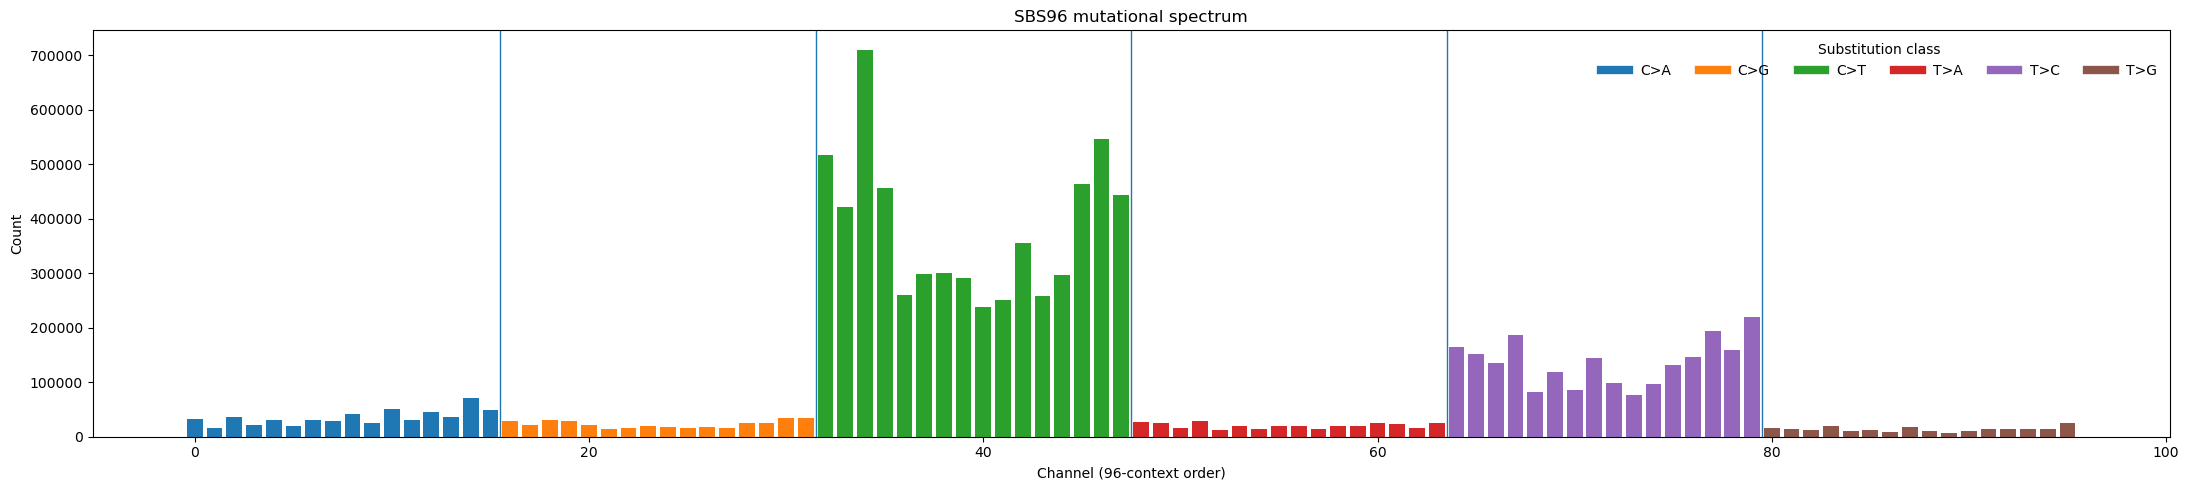

In [5]:
plot_sbs96(germ_maf_fold_sbs96)
plt.show()

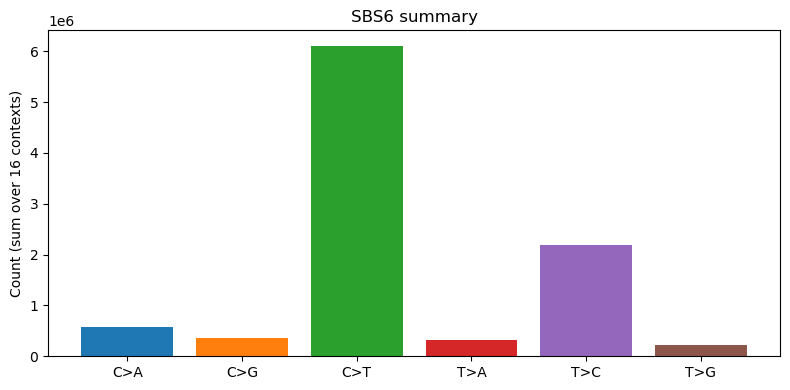

SUBSTITUTION
C>A     568120
C>G     368745
C>T    6106370
T>A     326520
T>C    2186690
T>G     221246
Name: COUNT, dtype: int64

In [6]:
plot_sbs6(germ_maf_fold_sbs96)

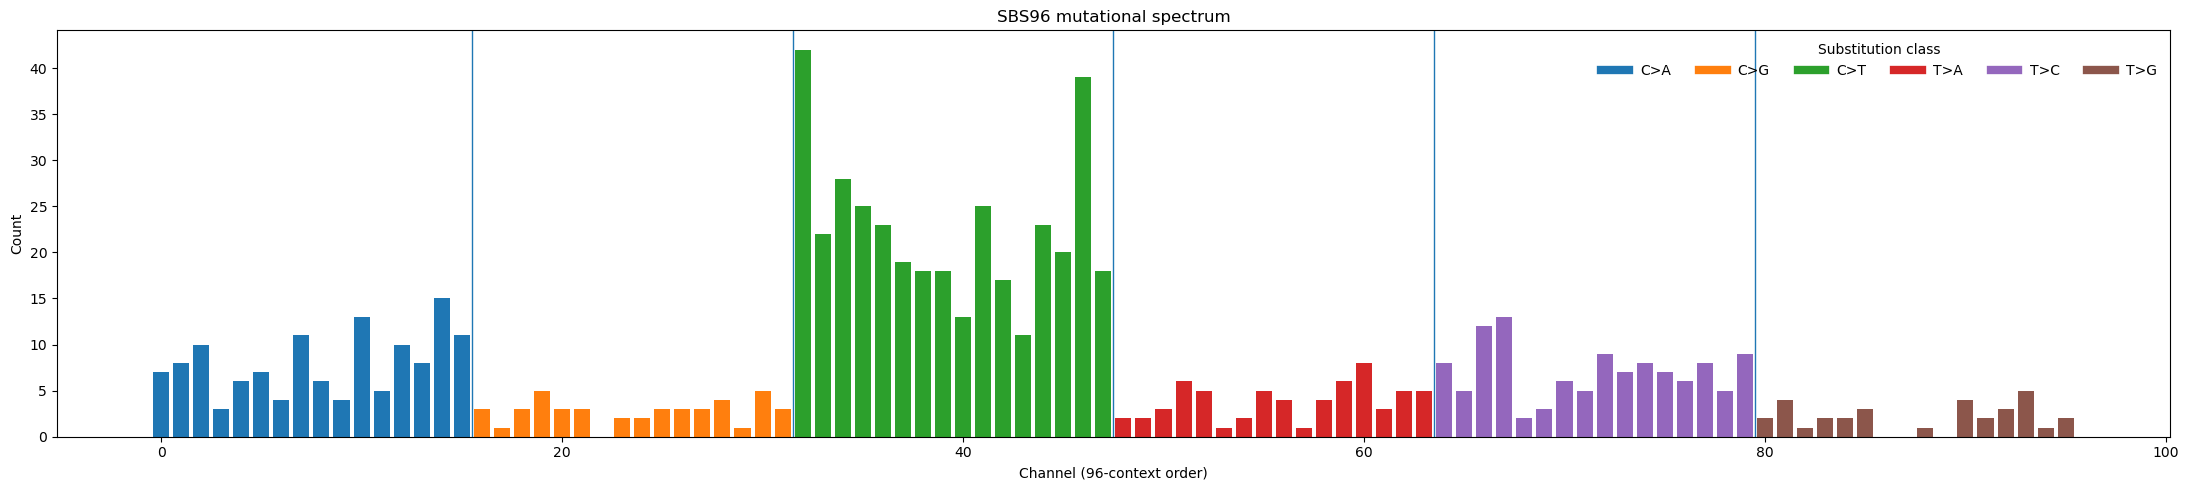

0      7
1      8
2     10
3      3
4      6
      ..
91     2
92     3
93     5
94     1
95     2
Name: COUNT, Length: 96, dtype: int64

In [7]:
plot_sbs96(somatic_sbs96)

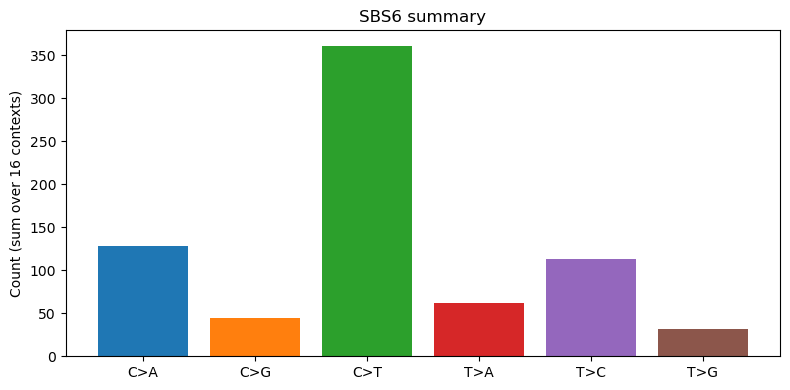

SUBSTITUTION
C>A    128
C>G     44
C>T    361
T>A     62
T>C    113
T>G     32
Name: COUNT, dtype: int64

In [8]:
plot_sbs6(somatic_sbs96)

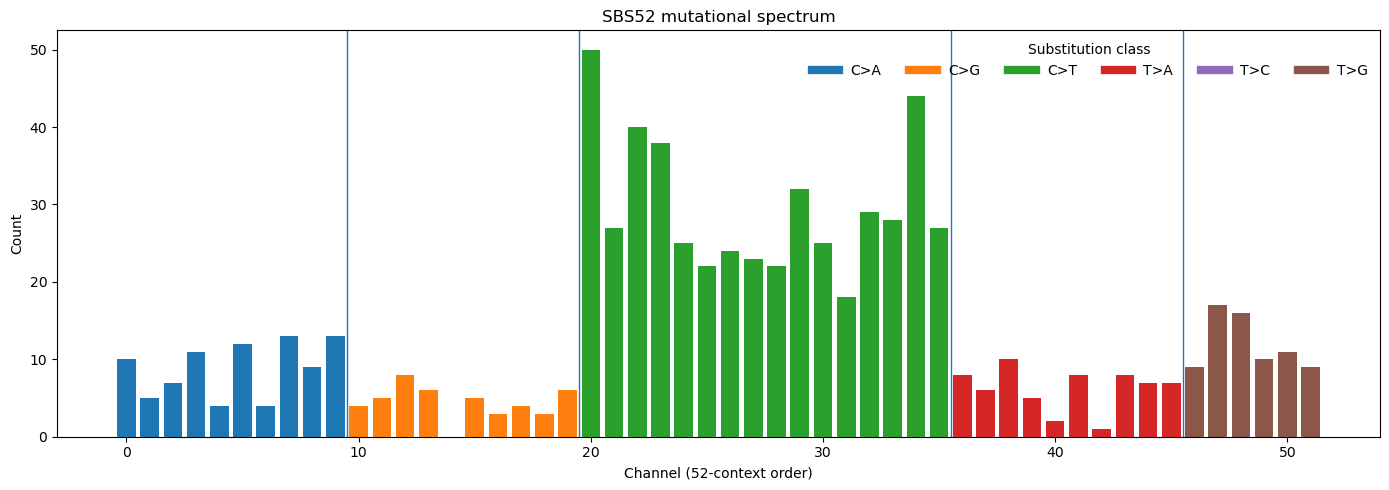

In [10]:
plot_sbs52(somatic_sbs52)
plt.show()

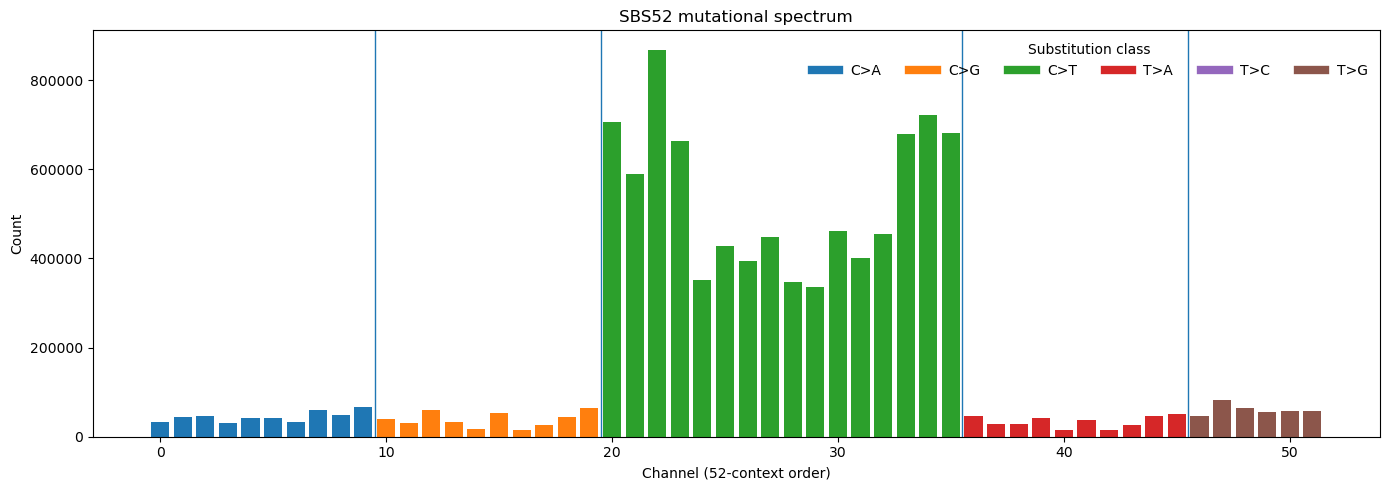

In [12]:
plot_sbs52(germ_sbs52)
plt.show()

In [20]:
somatic_sbs96.COUNT.sum()

np.int64(740)

In [28]:
! zcat ../../data/somatic.pool.batch_3_batch4.vcf.gz | grep -v "#" | wc -l

1446
